# Evaluasi Model RF dan SVM – 7 Sesi Data Uji

**Alur kerja:**
1. Load 7 file CSV data uji (per sesi)
2. Tiap sesi dihitung fiturnya secara mandiri (lag mulai dari 0)
3. Semua hasil digabung
4. Evaluasi RF dan SVM (klasifikasi + prediksi)
5. Tampilkan perbandingan

**Jalankan sel secara berurutan: SEL 1 → 2 → 3 → 4 → 5 → 6**

## SEL 1 – Install library

In [ ]:
!pip install scikit-learn==1.6.1 joblib pandas numpy matplotlib seaborn --quiet
print('Install selesai.')

Install selesai.


## SEL 2 – Load semua model

Upload file-file berikut ke Colab:
- model_rf_klasifikasi.pkl
- model_rf_prediksi.pkl
- model_svm_klasifikasi.pkl
- model_svm_regresi.pkl
- scaler_svm.pkl
- scaler_svm_regresi.pkl
- data_uji_sesi1.csv s.d. data_uji_sesi7.csv

## SEL 3 – Load 7 sesi data uji & hitung fitur per sesi

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# Load model
rf_klas     = joblib.load('model_rf_klasifikasi.pkl')
rf_reg      = joblib.load('model_rf_prediksi.pkl')
svm_klas    = joblib.load('model_svm_klasifikasi.pkl')
svm_reg     = joblib.load('model_svm_regresi.pkl')
scaler_klas = joblib.load('scaler_svm.pkl')
scaler_reg  = joblib.load('scaler_svm_regresi.pkl')

label_map   = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
label_names = ['Rendah', 'Sedang', 'Tinggi']

print('Semua model berhasil dimuat.')
print(f'Fitur model: {list(rf_klas.feature_names_in_)}')

# ================================================================
# KONFIGURASI – sesuaikan nama file CSV per sesi
# ================================================================
SESI_FILES = [
    'sesi_31MEI.csv',
    'sesi_1JUNI.csv',
    'sesi_2JUNI.csv',
    'sesi_3JUNI.csv',
    'sesi_4JUNI.csv',
    'sesi_5JUNI.csv',
    'sesi_6JUNI.csv',
]

# Kolom fitur yang dibutuhkan model
FITUR = ['count', 'durasi aktif', 'lag1', 'lag2', 'lag3',
         'lag4', 'lag5', 'lag6', 'avg30', 'avg60', 'delta1']

# Threshold label aktual (sama dengan saat training)
def count_to_label(count):
    if count <= 0:
        return 0  # rendah
    elif count <= 4:
        return 1  # sedang
    else:
        return 2  # tinggi

def hitung_fitur_sesi(df):
    """
    Hitung fitur lag dan statistik untuk satu sesi.
    Lag dihitung dari awal (mulai 0) agar tidak tercampur antar sesi.
    """
    df = df.sort_values('t (interval)').reset_index(drop=True)

    # Fill NaN in essential feature columns before calculations
    # 'count' and 'durasi aktif' are direct features and used for other feature calculations
    df['count'] = df['count'].fillna(0)
    df['durasi aktif'] = df['durasi aktif'].fillna(0)

    df['lag1']  = df['count'].shift(1).fillna(0)
    df['lag2']  = df['count'].shift(2).fillna(0)
    df['lag3']  = df['count'].shift(3).fillna(0)
    df['lag4']  = df['count'].shift(4).fillna(0)
    df['lag5']  = df['count'].shift(5).fillna(0)
    df['lag6']  = df['count'].shift(6).fillna(0)
    df['avg30'] = df[['lag1','lag2','lag3']].mean(axis=1).round(4)
    df['avg60'] = df[['lag1','lag2','lag3','lag4','lag5','lag6']].mean(axis=1).round(4)
    df['delta1']= (df['count'] - df['lag1']).astype(float)

    # Label aktual dari threshold count
    df['label'] = df['count'].apply(count_to_label)

    # Target regresi: count 6 interval ke depan (1 jam)
    df['target_1jam'] = df['count'].shift(-6).fillna(0)

    return df

# Proses tiap sesi secara mandiri
hasil_sesi = []
for i, file in enumerate(SESI_FILES, 1):
    try:
        df_sesi = pd.read_csv(file)
        df_sesi = hitung_fitur_sesi(df_sesi)
        df_sesi['sesi'] = i  # tandai nomor sesi
        hasil_sesi.append(df_sesi)
        print(f'Sesi {i} ({file}): {len(df_sesi)} interval | '
              f'Rendah={sum(df_sesi["label"]==0)} '
              f'Sedang={sum(df_sesi["label"]==1)} '
              f'Tinggi={sum(df_sesi["label"]==2)}')
    except FileNotFoundError:
        print(f'[WARNING] File tidak ditemukan: {file} — dilewati.')

# Gabung semua sesi
df_all = pd.concat(hasil_sesi).reset_index(drop=True)

print(f'\nTotal data gabungan: {len(df_all)} interval')
print(f'Distribusi label keseluruhan:')
print(df_all['label'].map(label_map).value_counts())

Semua model berhasil dimuat.
Fitur model: ['count', 'durasi aktif', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'avg30', 'avg60', 'delta1']
Sesi 1 (sesi_31MEI.csv): 37 interval | Rendah=28 Sedang=2 Tinggi=7
Sesi 2 (sesi_1JUNI.csv): 39 interval | Rendah=9 Sedang=2 Tinggi=28
Sesi 3 (sesi_2JUNI.csv): 56 interval | Rendah=22 Sedang=8 Tinggi=26
Sesi 4 (sesi_3JUNI.csv): 24 interval | Rendah=15 Sedang=6 Tinggi=3
Sesi 5 (sesi_4JUNI.csv): 18 interval | Rendah=3 Sedang=4 Tinggi=11
Sesi 6 (sesi_5JUNI.csv): 21 interval | Rendah=4 Sedang=1 Tinggi=16
Sesi 7 (sesi_6JUNI.csv): 12 interval | Rendah=5 Sedang=2 Tinggi=5

Total data gabungan: 207 interval
Distribusi label keseluruhan:
label
Tinggi    96
Rendah    86
Sedang    25
Name: count, dtype: int64


## SEL 4 – Evaluasi model klasifikasi (RF dan SVM)

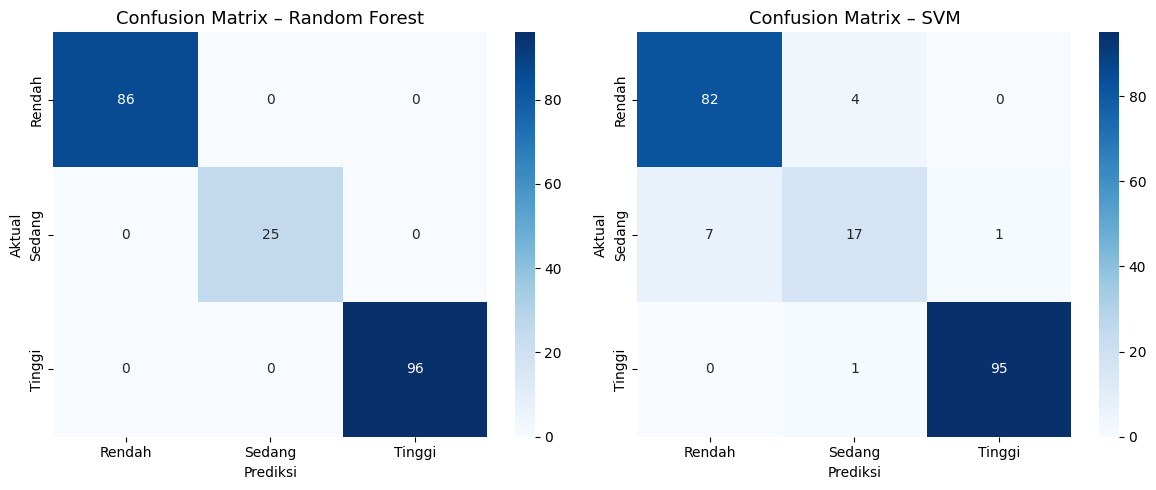

Gambar disimpan: confusion_matrix_klasifikasi.png

RANDOM FOREST – Classification Report
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        86
      Sedang       1.00      1.00      1.00        25
      Tinggi       1.00      1.00      1.00        96

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207

SVM – Classification Report
              precision    recall  f1-score   support

      Rendah       0.92      0.95      0.94        86
      Sedang       0.77      0.68      0.72        25
      Tinggi       0.99      0.99      0.99        96

    accuracy                           0.94       207
   macro avg       0.89      0.87      0.88       207
weighted avg       0.94      0.94      0.94       207



In [ ]:
X_test = df_all[FITUR]
y_klas = df_all['label']

# Scale untuk SVM
X_test_scaled_klas = scaler_klas.transform(X_test)

# Prediksi
pred_rf_klas  = rf_klas.predict(X_test)
pred_svm_klas = svm_klas.predict(X_test_scaled_klas)

# ---- Confusion Matrix ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(
    axes,
    [pred_rf_klas, pred_svm_klas],
    ['Random Forest', 'SVM']
):
    cm = confusion_matrix(y_klas, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'Confusion Matrix – {title}', fontsize=13)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_klasifikasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: confusion_matrix_klasifikasi.png')

# ---- Classification Report ----
print('\n' + '='*55)
print('RANDOM FOREST – Classification Report')
print('='*55)
print(classification_report(y_klas, pred_rf_klas, target_names=label_names))

print('='*55)
print('SVM – Classification Report')
print('='*55)
print(classification_report(y_klas, pred_svm_klas, target_names=label_names))

## SEL 5 – Evaluasi model prediksi/regresi (RF dan SVM)

EVALUASI MODEL PREDIKSI (REGRESI)

Random Forest Regressor
  MAE  : 7.7938
  RMSE : 9.8418
  R²   : -0.0052

SVM Regressor
  MAE  : 7.1941
  RMSE : 11.0847
  R²   : -0.2751

Ringkasan:
                            MAE     RMSE      R²
Model                                           
Random Forest Regressor  7.7938   9.8418 -0.0052
SVM Regressor            7.1941  11.0847 -0.2751


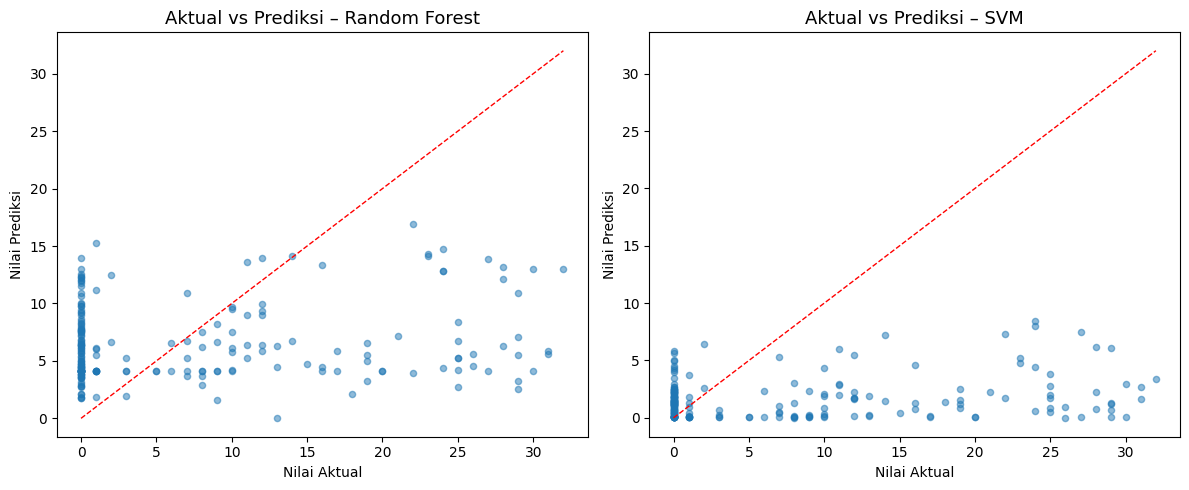

Gambar disimpan: scatter_regresi.png


In [ ]:
y_reg = df_all['target_1jam']

# Scale untuk SVM
X_test_scaled_reg = scaler_reg.transform(X_test)

# Prediksi
pred_rf_reg  = rf_reg.predict(X_test)
pred_svm_reg = svm_reg.predict(X_test_scaled_reg)

# Hitung metrik
def eval_regresi(y_true, y_pred, nama):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n{nama}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'Model': nama, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}

print('='*55)
print('EVALUASI MODEL PREDIKSI (REGRESI)')
print('='*55)
hasil_rf  = eval_regresi(y_reg, pred_rf_reg,  'Random Forest Regressor')
hasil_svm = eval_regresi(y_reg, pred_svm_reg, 'SVM Regressor')

df_reg = pd.DataFrame([hasil_rf, hasil_svm]).set_index('Model')
print('\nRingkasan:')
print(df_reg)

# Plot aktual vs prediksi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(
    axes,
    [pred_rf_reg, pred_svm_reg],
    ['Random Forest', 'SVM']
):
    ax.scatter(y_reg, pred, alpha=0.5, s=20)
    ax.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=1)
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
    ax.set_title(f'Aktual vs Prediksi – {title}', fontsize=13)

plt.tight_layout()
plt.savefig('scatter_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: scatter_regresi.png')

## SEL 6 – Ringkasan perbandingan RF vs SVM

RINGKASAN PERBANDINGAN – KLASIFIKASI (%)
               Akurasi  Precision  Recall  F1-Score
Model                                              
Random Forest   100.00      100.0  100.00    100.00
SVM              93.72       93.5   93.72     93.56

RINGKASAN PERBANDINGAN – PREDIKSI (REGRESI)
                            MAE     RMSE      R²
Model                                           
Random Forest Regressor  7.7938   9.8418 -0.0052
SVM Regressor            7.1941  11.0847 -0.2751


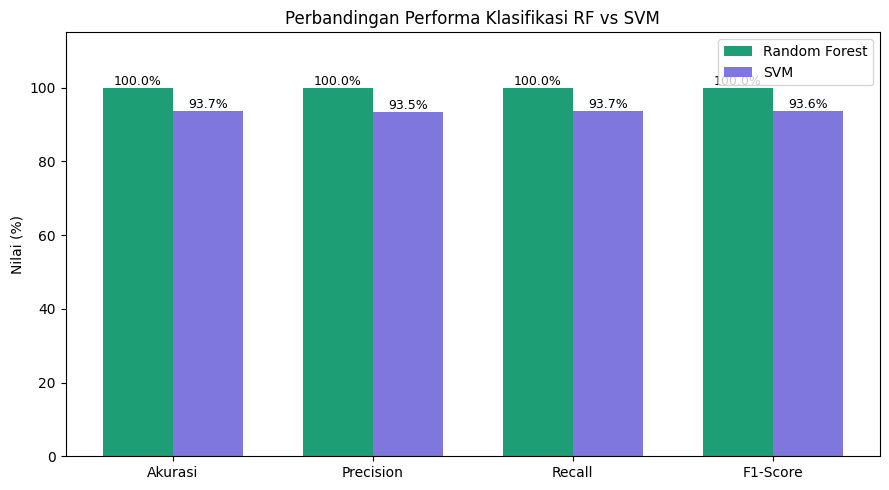

Gambar disimpan: perbandingan_rf_svm.png


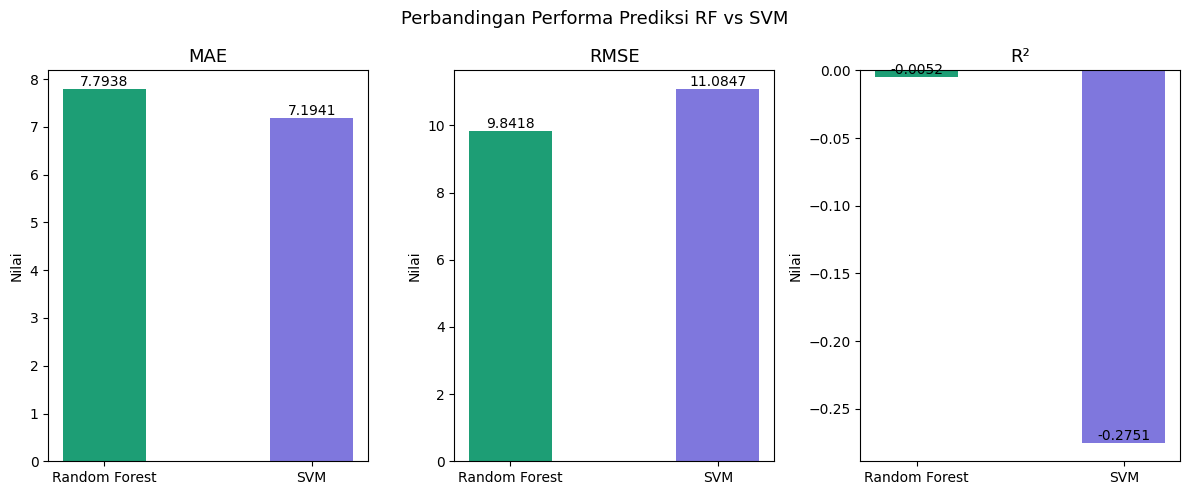

Gambar disimpan: perbandingan_regresi_rf_svm.png


In [ ]:
# Tabel ringkasan klasifikasi
def metrics_klas(y_true, y_pred, nama):
    return {
        'Model'    : nama,
        'Akurasi'  : round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted')*100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted')*100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted')*100, 2),
    }

df_klas = pd.DataFrame([
    metrics_klas(y_klas, pred_rf_klas,  'Random Forest'),
    metrics_klas(y_klas, pred_svm_klas, 'SVM'),
]).set_index('Model')

print('='*60)
print('RINGKASAN PERBANDINGAN – KLASIFIKASI (%)')
print('='*60)
print(df_klas.to_string())

print('\n' + '='*60)
print('RINGKASAN PERBANDINGAN – PREDIKSI (REGRESI)')
print('='*60)
print(df_reg.to_string())

# Bar chart klasifikasi
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(metrics))
width   = 0.35

ax.bar(x - width/2, [df_klas.loc['Random Forest', m] for m in metrics],
       width, label='Random Forest', color='#1D9E75')
ax.bar(x + width/2, [df_klas.loc['SVM', m] for m in metrics],
       width, label='SVM', color='#7F77DD')

ax.set_ylabel('Nilai (%)')
ax.set_title('Perbandingan Performa Klasifikasi RF vs SVM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 115)
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('perbandingan_rf_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: perbandingan_rf_svm.png')

# Bar chart regresi
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, metrik in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals   = [df_reg.loc['Random Forest Regressor', metrik],
              df_reg.loc['SVM Regressor', metrik]]
    colors = ['#1D9E75', '#7F77DD']
    bars   = ax.bar(['Random Forest', 'SVM'], vals, color=colors, width=0.4)
    ax.set_title(metrik, fontsize=13)
    ax.set_ylabel('Nilai')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.4f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Performa Prediksi RF vs SVM', fontsize=13)
plt.tight_layout()
plt.savefig('perbandingan_regresi_rf_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: perbandingan_regresi_rf_svm.png')